<a href="https://colab.research.google.com/github/a4kashhh/Graph-Neural-Network/blob/main/Node_Classification_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import os
import torch
os.environ["TORCH"]=torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

#visual prt

%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h,color):
  z = TSNE(n_components = 2 ).fit_transform(h.detach().cpu().numpy())
  plt.figure(figsize=(10,10))
  plt.xticks([])
  plt.yticks([])
  plt.scatter(z[:,0],z[:,1],s=70,c=color,cmap="Set2")
  plt.show()

2.10.0+cpu
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Node Classification using Graph Neural Networks (GNNs)

Node Classification is one of the most important tasks in Graph Neural Networks (GNNs).  
The objective is to predict the category or label of nodes present in a graph using node features and graph connectivity information.

In this implementation, we use the **Cora Citation Network Dataset**, a widely used benchmark dataset for graph based deep learning.

### Dataset Overview

- **Nodes** represent research papers
- **Edges** represent citation links between papers
- **Features** represent important words present in each document

If one paper cites another paper, a connection (edge) is formed between them.

Each node in the dataset contains:
- **1433 input features**
- **7 output classes/categories**

The goal is to predict the category of unlabeled papers by learning from:
- neighboring nodes
- graph structure
- node feature information

Graph Neural Networks perform this task through a process called **message passing**, where each node gathers information from its neighboring nodes and updates its representation iteratively.

This notebook uses **PyTorch Geometric (PyG)**, a powerful library built on top of PyTorch for implementing Graph Neural Networks efficiently.

In [37]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root="data/Planetoid",name="Cora",transform=NormalizeFeatures())
print()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]  # myfirst graph object.
print()
print(data)

print('(*_*)')
# Gatering statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: Cora():
Number of graphs: 1
Number of features: 1433
Number of classes: 7

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
(*_*)
Number of nodes: 2708
Number of edges: 10556
Average node degree: 3.90
Number of training nodes: 140
Training node label rate: 0.05
Has isolated nodes: False
Has self-loops: False
Is undirected: True


In [38]:
#model create
import torch
from torch.nn import Linear
import torch.nn.functional as F

class MLP(torch.nn.Module):
  def __init__(self,hidden_channel):
    super().__init__()
    self.lin1 = Linear(dataset.num_features,hidden_channel)
    self.lin2 = Linear(hidden_channel,dataset.num_classes)

  def forward(self,x):
    x = self.lin1(x)
    x = x.relu()
    x = F.dropout(x,p=0.5,training=self.training)
    x = self.lin2(x)
    return x

model=MLP(hidden_channel=16)
print(model)

MLP(
  (lin1): Linear(in_features=1433, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=7, bias=True)
)


# Multi Layer Perceptron (MLP)

The Multi Layer Perceptron (MLP) used in this implementation consists of two linear layers followed by ReLU activation and dropout regularization.

### Components Used

- **Linear Layers**  
  Perform feature transformation and learn important patterns from the input data.

- **ReLU Activation Function**  
  Introduces non-linearity into the network, allowing the model to learn complex relationships and patterns.

- **Dropout Layer**  
  Randomly disables some neurons during training to reduce overfitting and improve model generalization.

### Workflow

Input Features  
→ Linear Layer  
→ ReLU Activation  
→ Dropout  
→ Linear Layer  
→ Output Predictions

The combination of linear transformations, non-linearity, and regularization helps the model learn meaningful node representations effectively.

In [39]:
#training and evaluation

model = MLP(hidden_channel=16)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.01,weight_decay=5e-4)

def train():
  model.train()
  optimizer.zero_grad()
  out = model(data.x)
  loss = criterion(out[data.train_mask],data.y[data.train_mask])
  loss.backward()
  optimizer.step()
  return loss

def test():
  model.eval()
  out = model(data.x)
  pred = out.argmax(dim=1)
  test_correct = pred[data.test_mask] == data.y[data.test_mask]
  test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
  return test_acc

for epoch in range(1,201):
  loss = train()
  print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

test_acc = test()
print(f"Test Accuracy: {test_acc:.4f}")

Epoch: 001, Loss: 1.9556
Epoch: 002, Loss: 1.9523
Epoch: 003, Loss: 1.9485
Epoch: 004, Loss: 1.9432
Epoch: 005, Loss: 1.9376
Epoch: 006, Loss: 1.9312
Epoch: 007, Loss: 1.9282
Epoch: 008, Loss: 1.9205
Epoch: 009, Loss: 1.9104
Epoch: 010, Loss: 1.8965
Epoch: 011, Loss: 1.8893
Epoch: 012, Loss: 1.8838
Epoch: 013, Loss: 1.8717
Epoch: 014, Loss: 1.8599
Epoch: 015, Loss: 1.8542
Epoch: 016, Loss: 1.8306
Epoch: 017, Loss: 1.8252
Epoch: 018, Loss: 1.8142
Epoch: 019, Loss: 1.7996
Epoch: 020, Loss: 1.7977
Epoch: 021, Loss: 1.7548
Epoch: 022, Loss: 1.7748
Epoch: 023, Loss: 1.7413
Epoch: 024, Loss: 1.7255
Epoch: 025, Loss: 1.7071
Epoch: 026, Loss: 1.6698
Epoch: 027, Loss: 1.6407
Epoch: 028, Loss: 1.6577
Epoch: 029, Loss: 1.6016
Epoch: 030, Loss: 1.5912
Epoch: 031, Loss: 1.5394
Epoch: 032, Loss: 1.5499
Epoch: 033, Loss: 1.5533
Epoch: 034, Loss: 1.5138
Epoch: 035, Loss: 1.4853
Epoch: 036, Loss: 1.4653
Epoch: 037, Loss: 1.4353
Epoch: 038, Loss: 1.3961
Epoch: 039, Loss: 1.3950
Epoch: 040, Loss: 1.3596


# Performance Analysis of MLP

The Multi Layer Perceptron (MLP) achieves relatively low performance with nearly 59% test accuracy.

The primary reason behind this poor performance is **overfitting**.  
Since the model has access to only a small number of labeled training nodes, it fails to generalize effectively to unseen nodes during testing.

Another major limitation of MLP is that it completely ignores the graph structure and relationships between connected nodes.

In citation networks such as the Cora dataset:
- connected papers are often related to similar topics
- neighboring nodes usually share important semantic information

However, MLP processes each node independently and does not utilize neighbor information.

This is where **Graph Neural Networks (GNNs)** become highly effective.

GNNs use a mechanism called **message passing**, where nodes aggregate information from their neighboring nodes and update their representations iteratively.

By incorporating graph connectivity and neighborhood information, GNNs are able to learn more meaningful node representations and significantly improve node classification performance.

In [40]:
#now lets buuild MLP--->GCN

from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


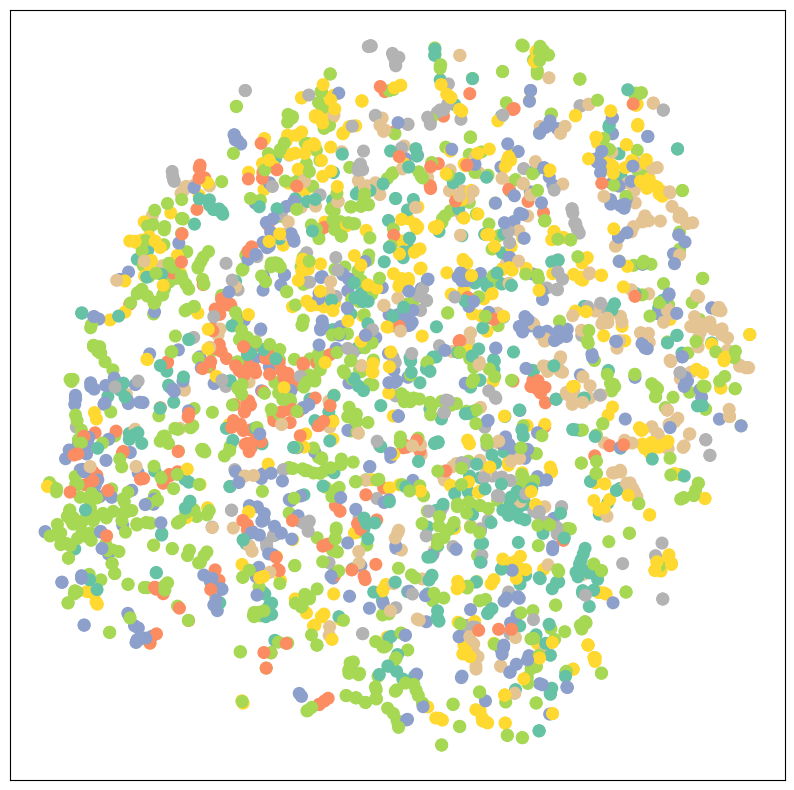

In [41]:
model =GCN(hidden_channels=16)
model.eval()
out=model(data.x,data.edge_index)
visualize(out,color=data.y)

In [44]:
#training our gcn
model = GCN(hidden_channels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()
      optimizer.zero_grad()
      out = model(data.x, data.edge_index)
      loss = criterion(out[data.train_mask], data.y[data.train_mask])
      loss.backward()
      optimizer.step()
      return loss
def test():
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)
      test_correct = pred[data.test_mask] == data.y[data.test_mask]
      test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
      return test_acc

for epoch in range(1, 101):
    loss = train()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Epoch: 001, Loss: 1.9465
Epoch: 002, Loss: 1.9419
Epoch: 003, Loss: 1.9363
Epoch: 004, Loss: 1.9290
Epoch: 005, Loss: 1.9199
Epoch: 006, Loss: 1.9140
Epoch: 007, Loss: 1.9079
Epoch: 008, Loss: 1.8992
Epoch: 009, Loss: 1.8876
Epoch: 010, Loss: 1.8764
Epoch: 011, Loss: 1.8656
Epoch: 012, Loss: 1.8626
Epoch: 013, Loss: 1.8460
Epoch: 014, Loss: 1.8329
Epoch: 015, Loss: 1.8225
Epoch: 016, Loss: 1.8167
Epoch: 017, Loss: 1.7995
Epoch: 018, Loss: 1.7878
Epoch: 019, Loss: 1.7716
Epoch: 020, Loss: 1.7568
Epoch: 021, Loss: 1.7563
Epoch: 022, Loss: 1.7342
Epoch: 023, Loss: 1.7092
Epoch: 024, Loss: 1.7015
Epoch: 025, Loss: 1.6671
Epoch: 026, Loss: 1.6757
Epoch: 027, Loss: 1.6609
Epoch: 028, Loss: 1.6355
Epoch: 029, Loss: 1.6339
Epoch: 030, Loss: 1.6102
Epoch: 031, Loss: 1.5964
Epoch: 032, Loss: 1.5721
Epoch: 033, Loss: 1.5570
Epoch: 034, Loss: 1.5445
Epoch: 035, Loss: 1.5093
Epoch: 036, Loss: 1.4889
Epoch: 037, Loss: 1.4776
Epoch: 038, Loss: 1.4704
Epoch: 039, Loss: 1.4263
Epoch: 040, Loss: 1.3972


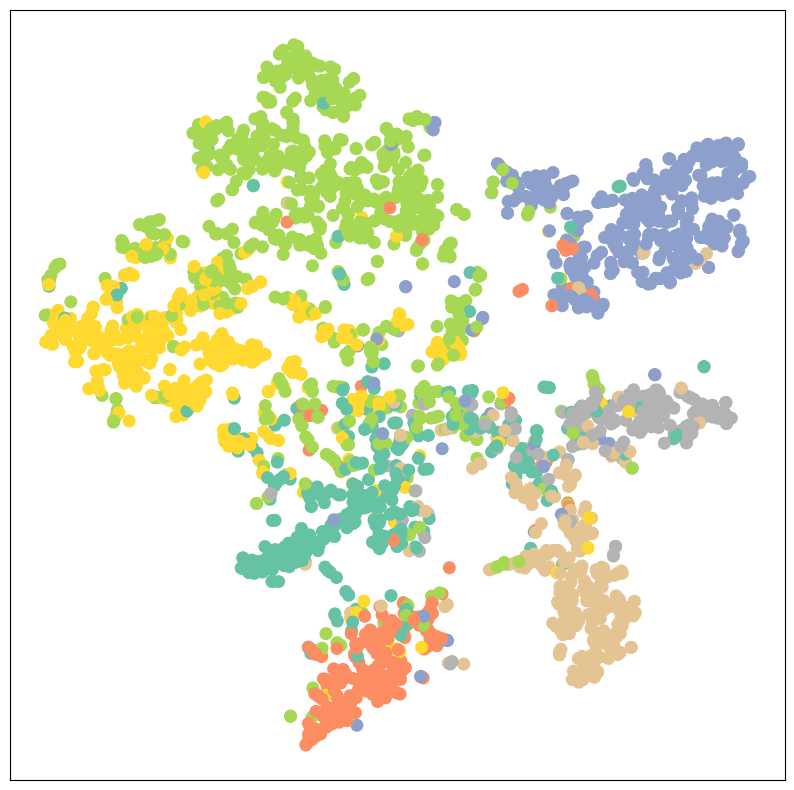

In [45]:
#final looking at our model with 81% accuracy
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

# Performance Improvement using Graph Convolutional Networks (GCN)

Initially, a Multi Layer Perceptron (MLP) model was used for node classification on the Cora citation network dataset.  
Although the model was able to learn basic patterns from node features, the overall test accuracy remained relatively low.

The primary reason for this poor performance was that the MLP treated every node independently and completely ignored the graph structure and relationships between connected nodes.

In the Cora dataset:
- nodes represent research papers
- edges represent citation links between papers

In real-world citation networks, papers that cite each other are often related to similar topics.  
However, the MLP model was unable to utilize this important neighborhood information.

As a result:
- the model suffered from overfitting
- learned weak node representations
- generalized poorly on unseen nodes

The visualization generated using MLP showed highly scattered embeddings where nodes from different classes were mixed together without clear separation.

To solve this limitation, the model was upgraded to a **Graph Convolutional Network (GCN)**.

Unlike MLP, GCN uses a process called **message passing**, where each node collects and aggregates information from its neighboring nodes before updating its own representation.

This allows the model to learn:
- node features
- graph connectivity
- neighborhood relationships
- structural information

The GCN model was built using:
- Graph Convolutional Layers (GCNConv)
- ReLU activation
- Dropout regularization

The training process also improved significantly:
- better feature propagation
- neighborhood aggregation
- improved generalization
- reduced overfitting

During training, the model continuously updated node embeddings by learning from nearby connected nodes.  
As the number of epochs increased, nodes belonging to similar categories gradually moved closer together in the embedding space.

The final visualization clearly demonstrates this improvement:
- nodes from the same classes formed compact clusters
- class boundaries became more distinguishable
- embeddings became more organized and meaningful

This clustering behavior indicates that the GCN successfully learned the hidden relationships between connected papers.

In simple words, the model became smarter because it no longer looked at each node alone.  
Instead, it also learned from the node's neighbors and surrounding connections.

This experiment clearly shows why Graph Neural Networks are much more powerful than traditional neural networks for graph structured data.

Overall, the transition from MLP to GCN resulted in:
- better node representations
- improved class separation
- higher prediction accuracy
- stronger generalization capability
- more meaningful graph embeddings

This demonstrates the effectiveness of Graph Neural Networks in tasks such as:
- node classification
- community detection
- recommendation systems
- social network analysis
- citation network learning
```